In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

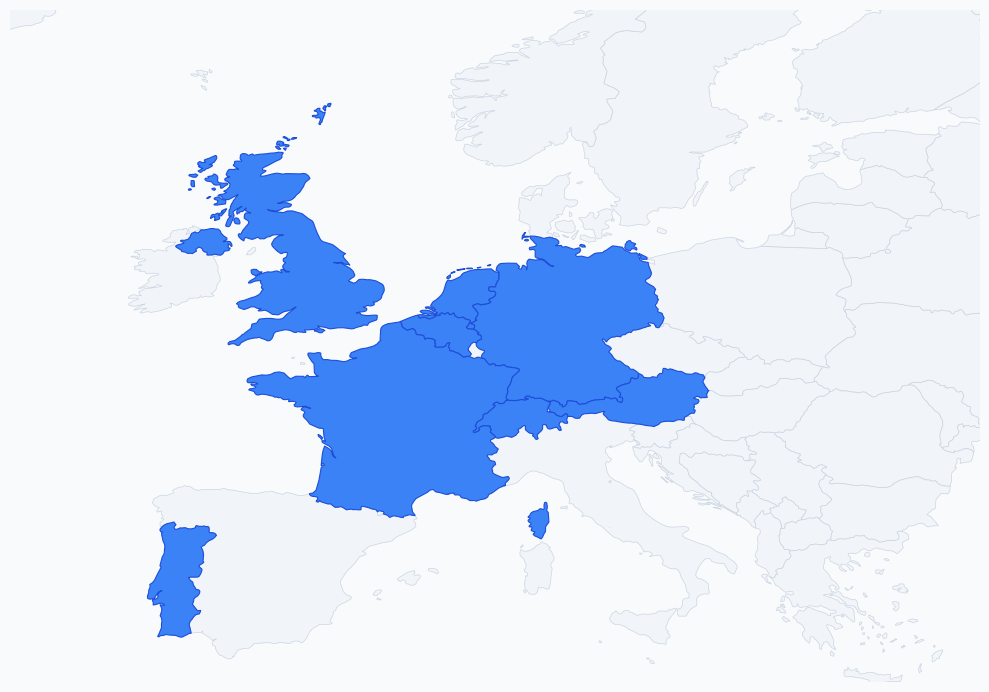

In [11]:
# Natural Earth 50m countries (replaces removed gpd.datasets / geodatasets lowres)
NE_COUNTRIES = (
    "https://naciscdn.org/naturalearth/50m/cultural/"
    "ne_50m_admin_0_countries.zip"
)
world = gpd.read_file(NE_COUNTRIES)
world = world.rename(columns=str.lower)

# Filter for Europe
europe = world[world["continent"] == "Europe"]

# 3. Define countries (Note: 'United Kingdom' matches the dataset name)
highlight_countries = [
    'Germany', 'Netherlands', 'Belgium', 'Portugal', 
    'Switzerland', 'United Kingdom', 'France', 'Austria'
]

# 4. Separate data
highlighted_gdf = europe[europe['name'].isin(highlight_countries)]
other_gdf = europe[~europe['name'].isin(highlight_countries)]

# 5. Create the plot
fig, ax = plt.subplots(figsize=(10, 10), facecolor='#f8fafc')
ax.set_facecolor('#bae6fd') # Soft ocean blue

# Plot background countries
other_gdf.plot(ax=ax, color='#f1f5f9', edgecolor='#cbd5e1', linewidth=0.5)

# Plot highlighted countries
highlighted_gdf.plot(ax=ax, color='#3b82f6', edgecolor='#1d4ed8', linewidth=0.8)

# 6. Center the view on Western/Central Europe
ax.set_xlim(-16, 30)
ax.set_ylim(35, 65)

# 7. Final Polish
#ax.set_title('Highlighted European Nations', fontsize=14, color='#1e293b', pad=15)
ax.axis('off')

plt.tight_layout()
plt.savefig('junk.png', dpi=300, bbox_inches='tight')